# 🟠 Lesson 19 — Cartopy

**Level: Advanced** · Publication-quality maps with real projections — the Matplotlib of cartography.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import cartopy
print("cartopy", cartopy.__version__)

DATA = Path("..") / "data"
q = pd.read_csv(DATA / "earthquakes.csv")
q.columns = ["date", "time", "lat", "lon", "depth_km", "magnitude"]

cartopy 0.25.0


## 1. A GeoAxes is a Matplotlib axes with a projection
`stock_img()` uses a bundled background image, so this works offline.
(Coastline/border features download Natural Earth data on first use.)

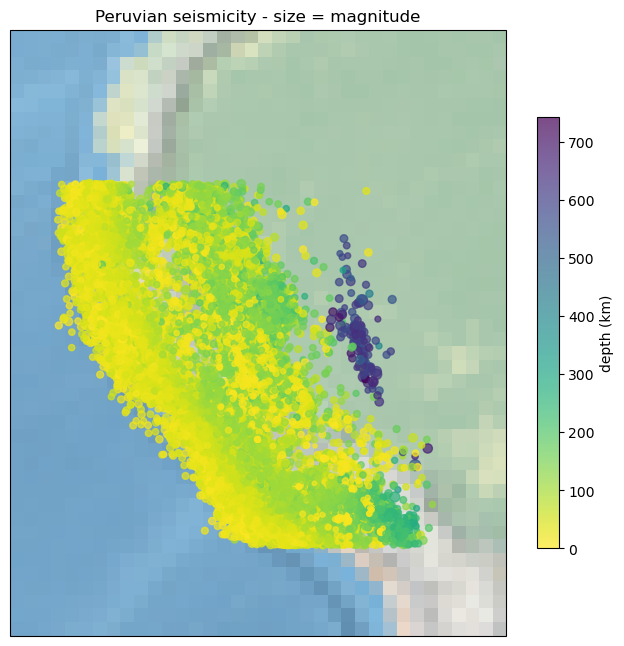

In [2]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-84, -66, -20, 2], crs=ccrs.PlateCarree())
ax.stock_img()

sc = ax.scatter(q["lon"], q["lat"], c=q["depth_km"], s=q["magnitude"]**2,
                cmap="viridis_r", alpha=0.7, transform=ccrs.PlateCarree())
plt.colorbar(sc, label="depth (km)", shrink=0.7)
ax.set_title("Peruvian seismicity - size = magnitude")
plt.show()

## 2. Gridlines with labels

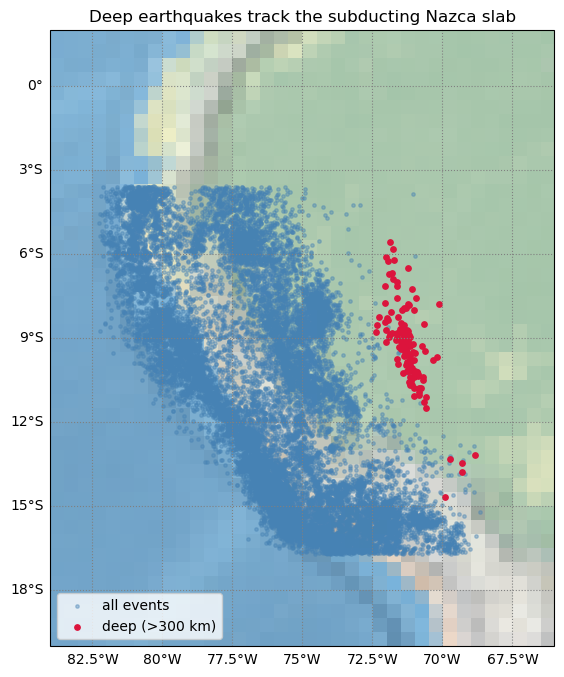

In [3]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-84, -66, -20, 2])
ax.stock_img()
gl = ax.gridlines(draw_labels=True, ls=":", color="gray")
gl.top_labels = gl.right_labels = False

deep = q[q["depth_km"] > 300]
ax.scatter(q["lon"], q["lat"], s=6, c="steelblue", alpha=0.4, label="all events")
ax.scatter(deep["lon"], deep["lat"], s=15, c="crimson", label="deep (>300 km)")
ax.legend(loc="lower left")
ax.set_title("Deep earthquakes track the subducting Nazca slab")
plt.show()

## 3. Changing projection is one argument
The same data, on an orthographic globe centred on Peru.

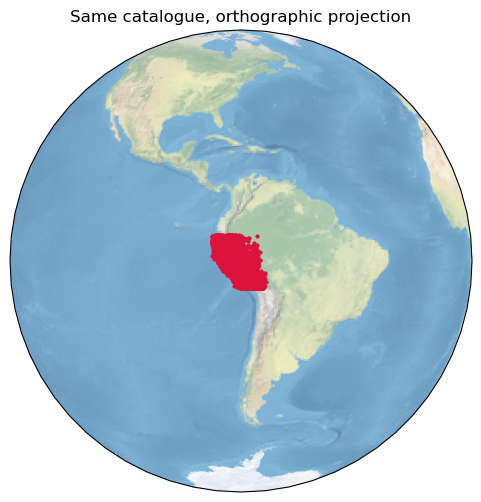

In [4]:
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=-75, central_latitude=-10))
ax.stock_img()
ax.scatter(q["lon"], q["lat"], s=4, c="crimson", transform=ccrs.PlateCarree())
ax.set_title("Same catalogue, orthographic projection")
plt.show()

## 4. Online features (needs internet once)
Natural Earth coastlines, borders and rivers download automatically and are cached locally:
```python
import cartopy.feature as cfeature
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, ls=':')
ax.add_feature(cfeature.RIVERS)
```

### ✏️ Try it
1. Plot only M ≥ 7 events with `ccrs.Mollweide()` — do they align with the trench?
2. Add `cfeature.COASTLINE` (requires internet on first run) and compare with `stock_img`.

📚 Docs: https://scitools.org.uk/cartopy/docs/latest/